In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

dfTrain = torch.load(chunksFilePath / 'SampledData-10Percent-Clean-Train.pth', map_location="cpu", weights_only=False)
dfTest = torch.load(chunksFilePath / 'SampledData-10Percent-Clean-Test.pth', map_location="cpu", weights_only=False)

In [4]:
levelsColumns = [col for col in dfTrain.columns if 'level' in col]
imgDataCols = [col for col in dfTrain.columns if 'Band_' in col]

X_train = dfTrain.drop(columns=levelsColumns+['ID'])
X_test = dfTest.drop(columns=levelsColumns+['ID'])
Y_train = dfTrain[levelsColumns]
Y_test = dfTest[levelsColumns]

In [ ]:
batch_size = 128

# Convert features to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32, device=device)

# Convert labels to integers and create mapping for each level
label_encoders = {}
y_train_dict = {}
y_test_dict = {}

for col in levelsColumns:
    all_labels = pd.concat([Y_train[col], Y_test[col]])
    uniques = pd.Index(all_labels.unique())
    label_encoders[col] = uniques

    mapping = {label: i for i, label in enumerate(uniques)}

    y_train_dict[col] = torch.tensor(
        Y_train[col].map(mapping).values,
        dtype=torch.long,
        device=device)

    y_test_dict[col] = torch.tensor(
        Y_test[col].map(mapping).values,
        dtype=torch.long,
        device=device)

# Custom dataset class to handle multiple outputs
class MultiLabelDataset(TensorDataset):
    def __init__(self, features, targets_dict):
        self.features = features
        self.targets_dict = targets_dict
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = self.features[idx]
        y = {col: self.targets_dict[col][idx] for col in self.targets_dict.keys()}
        return x, y

# Create datasets and dataloaders
train_dataset = MultiLabelDataset(X_train_tensor, y_train_dict)
test_dataset = MultiLabelDataset(X_test_tensor, y_test_dict)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader: {len(train_loader)} batches of {batch_size}")
print(f"Test loader: {len(test_loader)} batches of {batch_size}")

Train loader: 3582 batches of 128
Test loader: 898 batches of 128


In [6]:
def computeF1Scores(outputs, targets):
    f1_scores = {}
    for level in outputs.keys():
        preds = torch.argmax(outputs[level], dim=1).cpu().numpy()
        trues = targets[level].cpu().numpy()
        
        tp = np.sum((preds == trues) & (trues != -1))
        fp = np.sum((preds != trues) & (preds != -1))
        fn = np.sum((preds != trues) & (trues != -1))
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        f1_scores[level] = f1
    return f1_scores

In [7]:
def weightedLoss(outputs, targets, label_smoothings, weights):
    total_loss = 0.0
    
    # Iterate through each level with its corresponding smoothing and weight
    for idx, level in enumerate(outputs.keys()):

        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothings[idx])

        # Compute loss for this level
        level_loss = criterion(outputs[level], targets[level])
        
        # Add weighted loss to total
        total_loss += weights[idx] * level_loss
    
    return total_loss

In [8]:
class NN(nn.Module):
    def __init__(self, input_size, output_sizes):
        super(NN, self).__init__()

        self.level_keys = list(output_sizes.keys())
        # Define layers here
        self.fc1 = nn.Linear(input_size, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, output_sizes['level0'])

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        level_outputs = [x, torch.zeros_like(x), torch.zeros_like(x), torch.zeros_like(x)]
        outputs = {k: v for k, v in zip(self.level_keys, level_outputs)}

        return outputs


In [9]:

counts = Y_train['level0'].value_counts()
eps = 1e-3  # prevents blow-up
class_weights = 1.0 / np.log1p(counts + eps)
class_weights /= class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(class_weights)
print(class_weights.min(), class_weights.max())



tensor([0.8180, 0.8545, 0.9776, 1.3500], device='cuda:0')
tensor(0.8180, device='cuda:0') tensor(1.3500, device='cuda:0')


C:\Users\yy21473\AppData\Local\Temp\ipykernel_29848\400335093.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)


In [10]:
epochs = 10

input_size = X_train_tensor.shape[1]
output_sizes = {col: len(label_encoders[col]) for col in levelsColumns}


model = NN(input_size=X_train.shape[1], output_sizes = output_sizes).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.CrossEntropyLoss()

summary(model, input_size=(input_size,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          75,776
              ReLU-2                  [-1, 512]               0
            Linear-3                    [-1, 4]           2,052
Total params: 77,828
Trainable params: 77,828
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.30
Estimated Total Size (MB): 0.31
----------------------------------------------------------------


In [11]:
bestF1 = {col: [] for col in levelsColumns}

trainF1Scores = {col: [] for col in levelsColumns}
trainLosses = []
testF1Scores = {col: [] for col in levelsColumns}
testLosses = []

for epoch in range(epochs):
    model.train()
    trainLoss = 0.0
    trainF1Epoch = {col: 0.0 for col in levelsColumns}

    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = {col: targets[col].to(device) for col in targets.keys()}

        optimiser.zero_grad()
        outputs = model(data)

        loss = loss_function(outputs['level0'], targets['level0'])
        loss.backward()
        optimiser.step()



        trainLoss += loss.item() * data.size(0)
        #print('Train loss.item:', loss.item())
        
        # Compute F1 scores for this batch
        batch_f1 = computeF1Scores(outputs, targets)
        for col in levelsColumns:
            trainF1Epoch[col] += batch_f1[col] * data.size(0)
        

    model.eval()
    testLoss = 0.0
    testF1Epoch = {col: 0.0 for col in levelsColumns}
    
    with torch.no_grad():
        for batch_idx, (data, targets) in enumerate(test_loader):
            data = data.to(device)
            targets = {col: targets[col].to(device) for col in targets.keys()}

            outputs = model(data)
            loss = loss_function(outputs['level0'], targets['level0'])

            testLoss += loss.item() * data.size(0)
            #print('test loss.item:', loss.item())
            
            # Compute F1 scores for this batch
            batch_f1 = computeF1Scores(outputs, targets)
            for col in levelsColumns:
                testF1Epoch[col] += batch_f1[col] * data.size(0)
    
    trainLoss /= len(train_loader.dataset)
    testLoss /= len(test_loader.dataset)
    trainLosses.append(trainLoss)
    testLosses.append(testLoss)
    
    # Average F1 scores
    for col in levelsColumns:
        trainF1Epoch[col] /= len(train_loader.dataset)
        testF1Epoch[col] /= len(test_loader.dataset)
        trainF1Scores[col].append(trainF1Epoch[col])
        testF1Scores[col].append(testF1Epoch[col])

    


    print(f"Epoch {epoch+1} | Train Loss: {trainLoss:.4f} | Test Loss: {testLoss:.4f} | Train F1 L0: {trainF1Epoch['level0']:.4f} | Test F1 L0: {testF1Epoch['level0']:.4f}")

Epoch 1 | Train Loss: 0.7979 | Test Loss: 0.7893 | Train F1 L0: 0.6534 | Test F1 L0: 0.6581
Epoch 2 | Train Loss: 0.7800 | Test Loss: 0.7744 | Train F1 L0: 0.6605 | Test F1 L0: 0.6646
Epoch 3 | Train Loss: 0.7723 | Test Loss: 0.7669 | Train F1 L0: 0.6654 | Test F1 L0: 0.6674
Epoch 4 | Train Loss: 0.7670 | Test Loss: 0.7622 | Train F1 L0: 0.6688 | Test F1 L0: 0.6709
Epoch 5 | Train Loss: 0.7633 | Test Loss: 0.7581 | Train F1 L0: 0.6714 | Test F1 L0: 0.6728
Epoch 6 | Train Loss: 0.7606 | Test Loss: 0.7624 | Train F1 L0: 0.6732 | Test F1 L0: 0.6735
Epoch 7 | Train Loss: 0.7584 | Test Loss: 0.7559 | Train F1 L0: 0.6743 | Test F1 L0: 0.6748
Epoch 8 | Train Loss: 0.7566 | Test Loss: 0.7563 | Train F1 L0: 0.6749 | Test F1 L0: 0.6752
Epoch 9 | Train Loss: 0.7551 | Test Loss: 0.7546 | Train F1 L0: 0.6762 | Test F1 L0: 0.6752
Epoch 10 | Train Loss: 0.7537 | Test Loss: 0.7518 | Train F1 L0: 0.6767 | Test F1 L0: 0.6775


(0.6, 1.0)

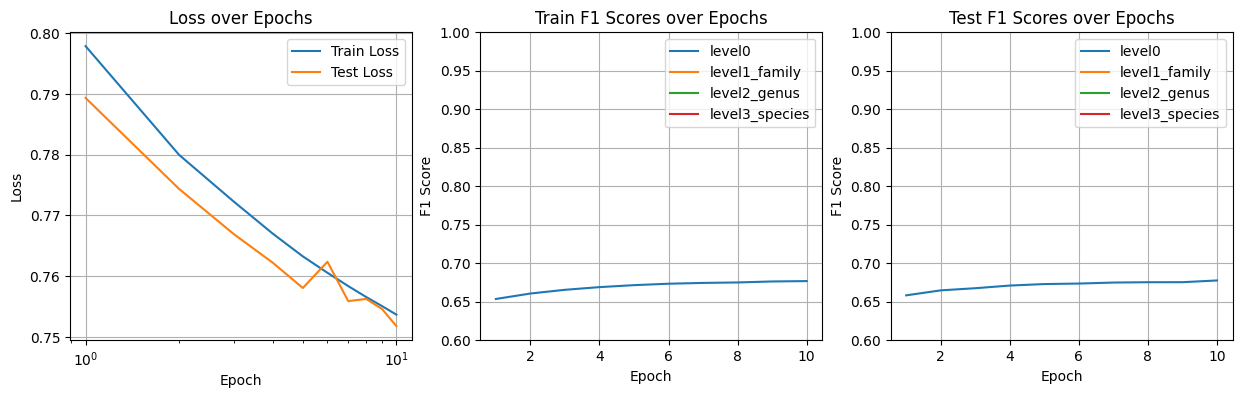

In [12]:
trainLosses = np.array(trainLosses)
testLosses = np.array(testLosses)

figLoss, axLoss = plt.subplots(ncols=3, figsize=(15, 4))

epochArr = np.arange(1, trainLosses.shape[0]+1, 1)

axLoss[0].plot(epochArr, trainLosses, label='Train Loss')
axLoss[0].plot(epochArr, testLosses, label='Test Loss')
axLoss[0].set_title('Loss over Epochs')
axLoss[0].set_xlabel('Epoch')
axLoss[0].set_ylabel('Loss')
axLoss[0].grid()
axLoss[0].set_xscale('log')
axLoss[0].legend()

# Train F1 scores
axTrainF1 = axLoss[1]
for col in levelsColumns:
    axTrainF1.plot(epochArr, trainF1Scores[col], label=f'{col}')

axTrainF1.set_title('Train F1 Scores over Epochs')
axTrainF1.set_xlabel('Epoch')
axTrainF1.set_ylabel('F1 Score')
axTrainF1.grid()
axTrainF1.legend()
axTrainF1.set_ylim(0.6, 1)

# Test F1 scores
axTestF1 = axLoss[2]
for col in levelsColumns:
    axTestF1.plot(epochArr, testF1Scores[col], label=f'{col}')

axTestF1.set_title('Test F1 Scores over Epochs')
axTestF1.set_xlabel('Epoch')
axTestF1.set_ylabel('F1 Score')
axTestF1.grid()
axTestF1.legend()
axTestF1.set_ylim(0.6, 1)

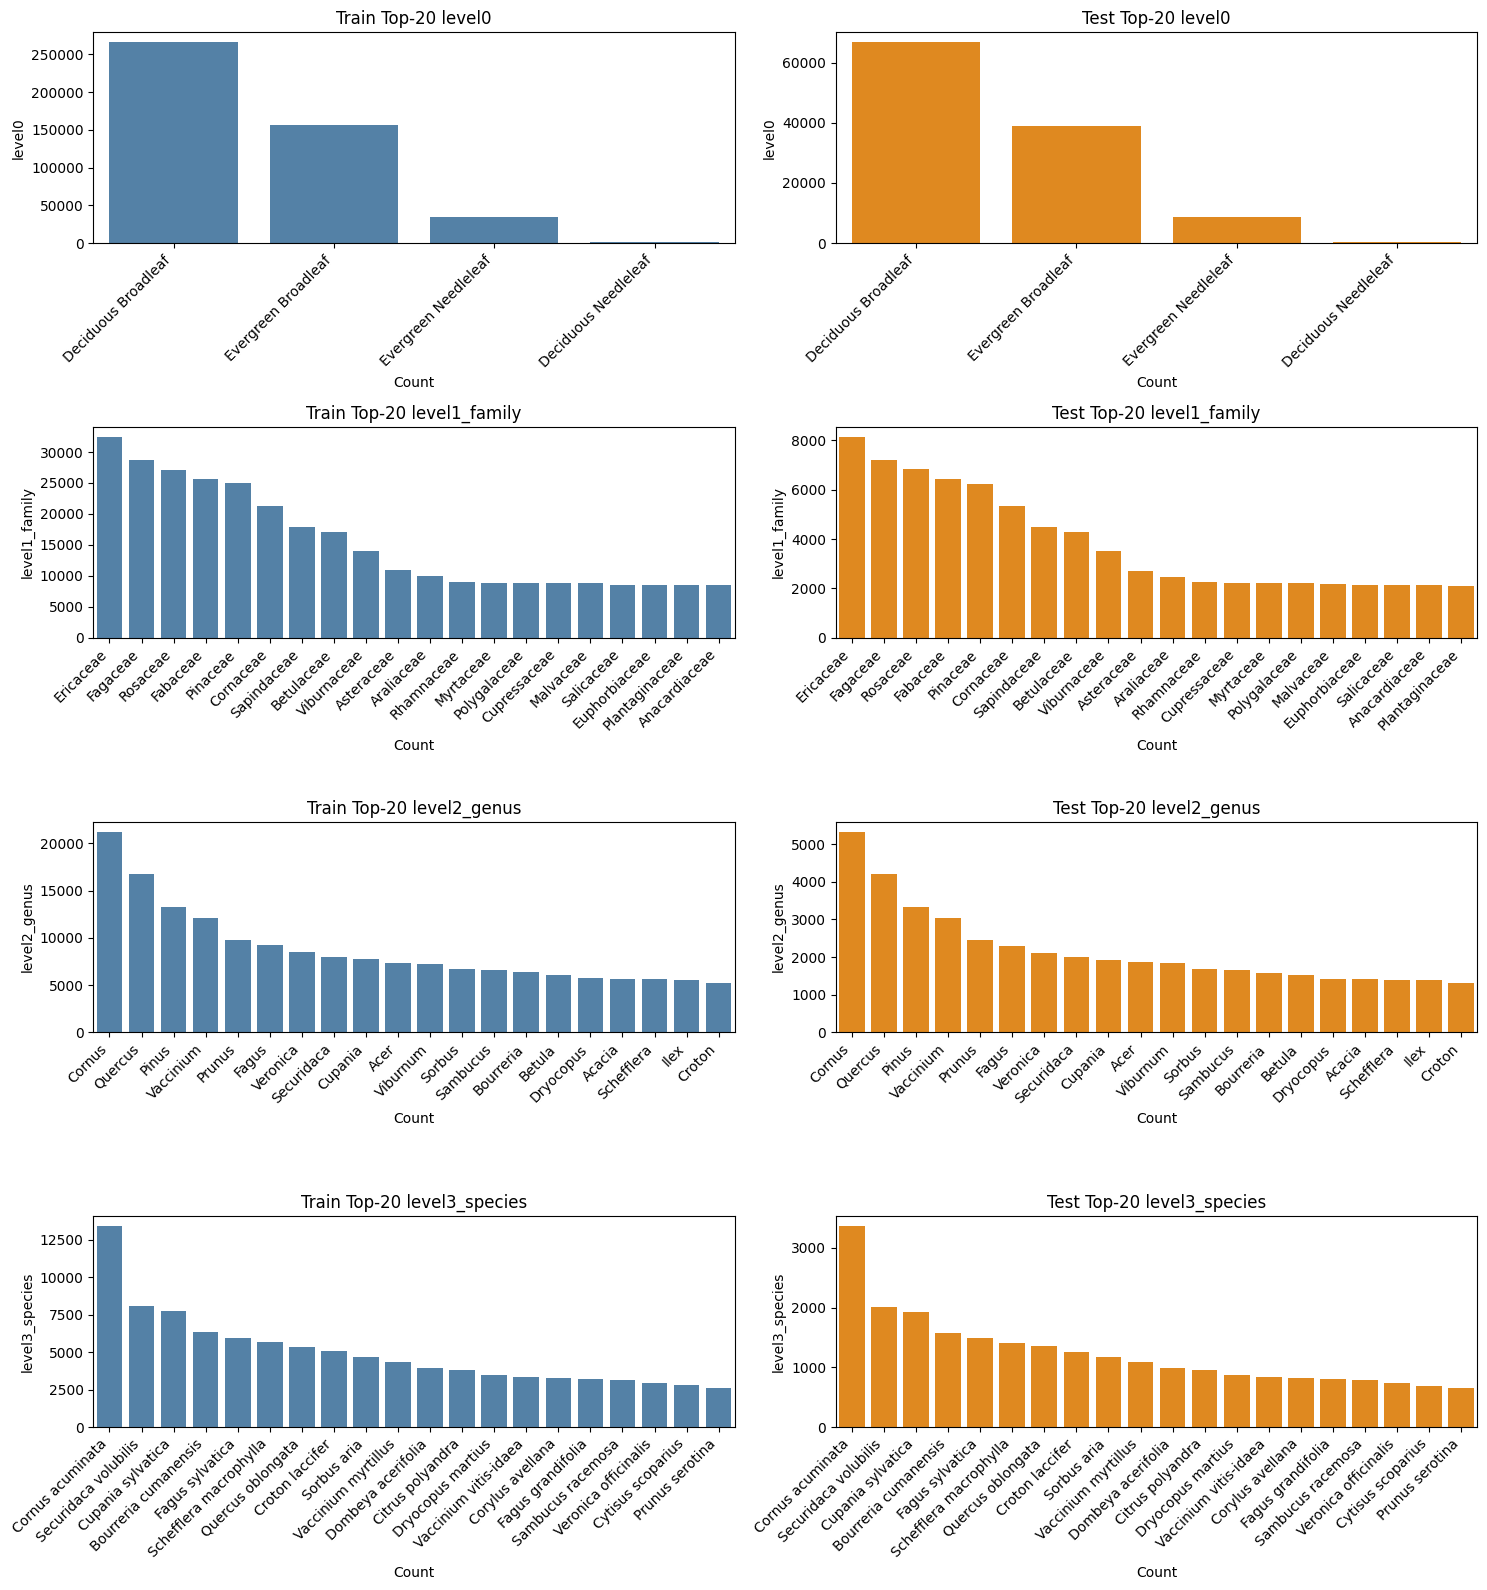

In [13]:
# check distributions
n_levels = len(levelsColumns)
fig, ax = plt.subplots(nrows=n_levels, ncols=2, figsize=(15, 4 * n_levels))

for i, col in enumerate(levelsColumns):
    train_counts = Y_train[col].value_counts().head(20)
    test_counts = Y_test[col].value_counts().head(20)
    
    train_df = train_counts.reset_index()
    train_df.columns = [col, 'count']
    sns.barplot(data=train_df, y='count', x=col, ax=ax[i][0], color='steelblue')
    ax[i][0].set_title(f'Train Top-20 {col}')
    ax[i][0].set_xlabel('Count')
    ax[i][0].set_ylabel(col)
    
    test_df = test_counts.reset_index()
    test_df.columns = [col, 'count']
    sns.barplot(data=test_df, y='count', x=col, ax=ax[i][1], color='darkorange')
    ax[i][1].set_title(f'Test Top-20 {col}')
    ax[i][1].set_xlabel('Count')
    ax[i][1].set_ylabel(col)

    for a in range(2):
        ax[i, a].tick_params(axis='x', rotation=45)
        for label in ax[i, a].get_xticklabels():
            label.set_horizontalalignment('right')
            label.set_verticalalignment('top')
    
plt.tight_layout()

In [14]:
Y_train['level3_species'].value_counts().sort_values(ascending=False).head(20)

level3_species
Cornus acuminata          13382
Securidaca volubilis       8041
Cupania sylvatica          7754
Bourreria cumanensis       6372
Fagus sylvatica            5939
Schefflera macrophylla     5651
Quercus oblongata          5357
Croton laccifer            5044
Sorbus aria                4683
Vaccinium myrtillus        4351
Dombeya acerifolia         3965
Citrus polyandra           3820
Dryocopus martius          3506
Vaccinium vitis-idaea      3358
Corylus avellana           3281
Fagus grandifolia          3204
Sambucus racemosa          3145
Veronica officinalis       2929
Cytisus scoparius          2811
Prunus serotina            2606
Name: count, dtype: int64

In [15]:
# model evaluation on test and train sets for confusoin matrixes
trainTrue = []
trainPred = []

testTrue = []
testPred = []

model.eval()

with torch.no_grad():
    for data, targets in train_loader:
        data = data.to(device)
        targets = {col: targets[col].to(device) for col in targets.keys()}

        outputs = model(data)

        preds = torch.argmax(outputs['level0'], dim=1)

        trainTrue.extend(targets['level0'].cpu().numpy())
        trainPred.extend(preds.cpu().numpy())

    for data, targets in test_loader:
        data = data.to(device)
        targets = {col: targets[col].to(device) for col in targets.keys()}

        outputs = model(data)

        preds = torch.argmax(outputs['level0'], dim=1)

        testTrue.extend(targets['level0'].cpu().numpy())
        testPred.extend(preds.cpu().numpy())


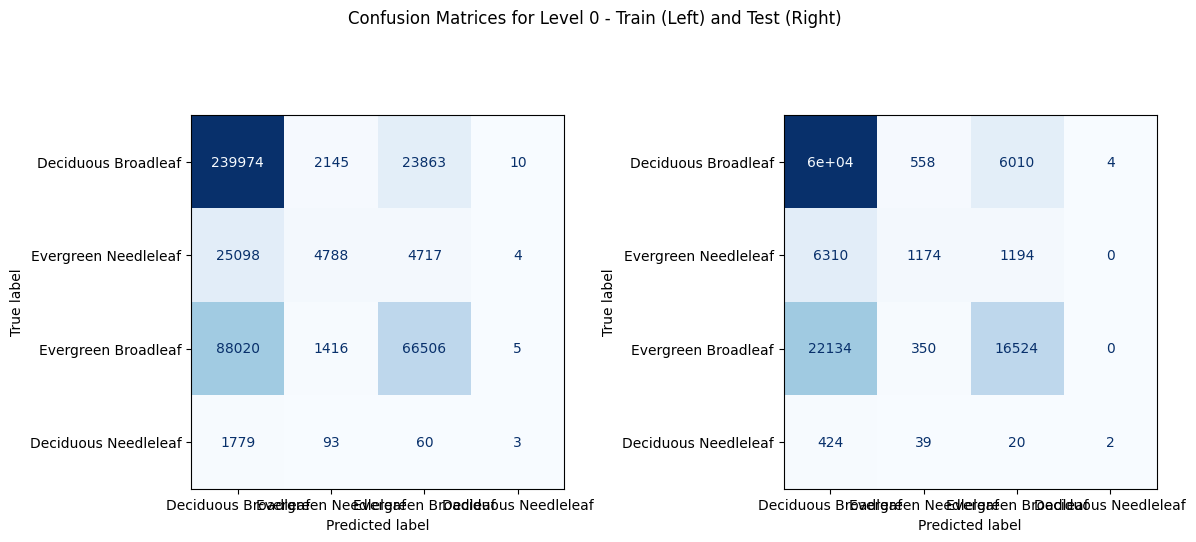

In [17]:
CMTrain = confusion_matrix(trainTrue, trainPred)
CMTest = confusion_matrix(testTrue, testPred)

figCM, axCM = plt.subplots(ncols=2, figsize=(12, 6))
dispTrain = ConfusionMatrixDisplay(confusion_matrix=CMTrain, display_labels=label_encoders['level0'])
dispTrain.plot(ax=axCM[0], cmap='Blues', colorbar=False)

dispTest = ConfusionMatrixDisplay(confusion_matrix=CMTest, display_labels=label_encoders['level0'])
dispTest.plot(ax=axCM[1], cmap='Blues', colorbar=False)

figCM.suptitle('Confusion Matrices for Level 0 - Train (Left) and Test (Right)')
figCM.tight_layout()